In [ ]:
!pip install langchain langgraph 

In [ ]:
!pip install dotenv

In [ ]:
from dotenv import load_dotenv
load_dotenv()


True

In [ ]:
from queue import deque



In [ ]:
!pip install langchain-nvidia-ai-endpoints langchain-core langchain-community

In [3]:
from langgraph.graph import StateGraph,START,END,add_messages
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from typing import TypedDict,Annotated,List,Literal,operator
from langchain_core.messages import BaseMessage,HumanMessage,SystemMessage,AIMessage
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode,tools_condition
from pathlib import Path
import string
import os
import shutil

C:\Users\kiran\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
!pip install rapidfuzz

In [ ]:
!pip install reportlab

In [4]:
model=ChatNVIDIA(model="meta/llama-3.1-70b-instruct")

In [ ]:
class StorageIntelligence(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]
@tool
def list_drives() -> dict:
    """Return all available drives on the system."""

    result = []

    for letter in string.ascii_uppercase:
        drive = f"{letter}:/"
        if os.path.exists(drive):
            result.append(drive)

    return {"drives": result}

import os
import heapq
from concurrent.futures import ThreadPoolExecutor, as_completed
from langchain.tools import tool

KB = 1024
MB = KB * 1024
GB = MB * 1024
TB = GB * 1024


def format_size(size: int) -> str:
    if size >= TB:
        return f"{size / TB:.2f} TB"
    if size >= GB:
        return f"{size / GB:.2f} GB"
    if size >= MB:
        return f"{size / MB:.2f} MB"
    if size >= KB:
        return f"{size / KB:.2f} KB"
    return f"{size} B"


def get_category(size: int) -> str:
    if size < 100 * MB:
        return "Small"
    elif size < 1 * GB:
        return "Medium"
    elif size < 5 * GB:
        return "Large"
    elif size < 10 * GB:
        return "Very Large"
    elif size < 25 * GB:
        return "Huge"
    elif size < 50 * GB:
        return "Massive"
    elif size < 100 * GB:
        return "Gigantic"
    elif size < 250 * GB:
        return "Storage Hog"
    elif size < 500 * GB:
        return "Extreme"
    elif size < 1 * TB:
        return "Monster"
    return "Colossal"


def scan_files(folder: str):
    """
    Scan one folder recursively and return file metadata.
    """

    results = []

    for root, _, files in os.walk(folder):

        for file in files:

            full_path = os.path.join(root, file)

            try:

                size = os.path.getsize(full_path)

                results.append({
                    "path": full_path,
                    "name": file,
                    "extension": os.path.splitext(file)[1].lower(),
                    "size_bytes": size,
                    "size": format_size(size),
                    "category": get_category(size)
                })

            except (PermissionError, FileNotFoundError, OSError):
                continue

    return results


@tool
def scan_largest_files(
    path: str,
    top_n: int = 20,
    min_size_mb: int = 100
):
    """
    Scan a drive/folder and return the largest files.

    Example:
        path="D:/"
        top_n=20
        min_size_mb=500
    """

    if not os.path.exists(path):
        return {"error": "Path not found"}

    if not os.path.isdir(path):
        return {"error": "Not a directory"}

    minimum_size = min_size_mb * MB

    all_files = []

    # Scan files directly in root
    try:
        with os.scandir(path) as entries:
            for entry in entries:

                if entry.is_file(follow_symlinks=False):

                    try:
                        size = entry.stat().st_size

                        all_files.append({
                            "path": entry.path,
                            "name": entry.name,
                            "extension": os.path.splitext(entry.name)[1].lower(),
                            "size_bytes": size,
                            "size": format_size(size),
                            "category": get_category(size)
                        })

                    except:
                        pass

    except:
        pass

    # Top-level folders
    folders = []

    try:
        with os.scandir(path) as entries:
            for entry in entries:
                if entry.is_dir(follow_symlinks=False):
                    folders.append(entry.path)
    except:
        pass

    workers = min(os.cpu_count() or 4, len(folders))

    if workers > 0:

        with ThreadPoolExecutor(max_workers=workers) as executor:

            futures = [
                executor.submit(scan_files, folder)
                for folder in folders
            ]

            for future in as_completed(futures):
                try:
                    all_files.extend(future.result())
                except:
                    pass

    # Filter
    all_files = [
        f for f in all_files
        if f["size_bytes"] >= minimum_size
    ]

    largest = heapq.nlargest(
        top_n,
        all_files,
        key=lambda x: x["size_bytes"]
    )

    return {
        "scanned_path": path,
        "total_files": len(all_files),
        "largest_files": largest
    }

import os
import heapq
from concurrent.futures import ThreadPoolExecutor, as_completed
from langchain.tools import tool

KB = 1024
MB = KB * 1024
GB = MB * 1024
TB = GB * 1024


def format_size(size: int) -> str:
    if size >= TB:
        return f"{size / TB:.2f} TB"
    if size >= GB:
        return f"{size / GB:.2f} GB"
    if size >= MB:
        return f"{size / MB:.2f} MB"
    if size >= KB:
        return f"{size / KB:.2f} KB"
    return f"{size} B"


def get_category(size: int) -> str:
    if size < 100 * MB:
        return "Small"
    elif size < 1 * GB:
        return "Medium"
    elif size < 5 * GB:
        return "Large"
    elif size < 10 * GB:
        return "Very Large"
    elif size < 25 * GB:
        return "Huge"
    elif size < 50 * GB:
        return "Massive"
    elif size < 100 * GB:
        return "Gigantic"
    elif size < 250 * GB:
        return "Storage Hog"
    elif size < 500 * GB:
        return "Extreme"
    elif size < 1 * TB:
        return "Monster"
    return "Colossal"


def calculate_folder_sizes(root_path: str):
    """
    Calculates folder sizes using ONE bottom-up traversal.
    Every file is visited exactly once.
    """

    folder_sizes = {}

    for root, dirs, files in os.walk(root_path, topdown=False):

        total = 0

        # Add file sizes
        for file in files:
            try:
                total += os.path.getsize(os.path.join(root, file))
            except (PermissionError, FileNotFoundError, OSError):
                pass

        # Add already calculated child folder sizes
        for d in dirs:
            total += folder_sizes.get(os.path.join(root, d), 0)

        folder_sizes[root] = total

    return folder_sizes


@tool
def scan_largest_folders(
    path: str,
    top_n: int = 20,
    min_size_gb: float = 1
):
    """
    Scan a drive or folder and return the largest folders.

    Example:
        path="D:/"
        top_n=20
        min_size_gb=5
    """

    if not os.path.exists(path):
        return {"error": "Path not found"}

    if not os.path.isdir(path):
        return {"error": "Not a directory"}

    minimum_size = int(min_size_gb * GB)

    merged_sizes = {}

    # Root files (if any)
    merged_sizes.update(calculate_folder_sizes(path))

    # Parallel scan of top-level folders
    top_level_dirs = []

    try:
        with os.scandir(path) as entries:
            for entry in entries:
                if entry.is_dir(follow_symlinks=False):
                    top_level_dirs.append(entry.path)
    except PermissionError:
        pass

    workers = min(os.cpu_count() or 4, len(top_level_dirs))

    if workers > 0:

        with ThreadPoolExecutor(max_workers=workers) as executor:

            futures = [
                executor.submit(calculate_folder_sizes, folder)
                for folder in top_level_dirs
            ]

            for future in as_completed(futures):
                try:
                    merged_sizes.update(future.result())
                except Exception:
                    pass

    folders = []

    for folder, size in merged_sizes.items():

        if size < minimum_size:
            continue

        folders.append({
            "path": folder,
            "size_bytes": size,
            "size": format_size(size),
            "category": get_category(size)
        })

    largest = heapq.nlargest(
        top_n,
        folders,
        key=lambda x: x["size_bytes"]
    )

    return {
        "scanned_path": path,
        "total_folders": len(folders),
        "largest_folders": largest
    }

@tool
def get_drive_info() -> list[dict]:
    """Return storage information for all available drives."""

    result = []

    for letter in string.ascii_uppercase:
        drive = f"{letter}:/"
        if os.path.exists(drive):
            total, used, free = shutil.disk_usage(drive)

            result.append({
                "drive": drive,
                "total_gb": round(total / (1024**3), 2),
                "used_gb": round(used / (1024**3), 2),
                "free_gb": round(free / (1024**3), 2),
                "usage_percent": round((used / total) * 100, 2),
            })

    return result


@tool
def list_folders_in_directory(path: str) -> dict:
    """
    List all folders in the given directory.
    Example paths:
    - C:/
    - D:/
    - C:/Users
    - D:/Movies
    """

    if not os.path.exists(path):
        return {"error": f"{path} does not exist."}

    if not os.path.isdir(path):
        return {"error": f"{path} is not a directory."}

    folders = []
    files = []

    try:
        for item in os.listdir(path):
            full_path = os.path.join(path, item)

            if os.path.isdir(full_path):
                folders.append(item)
            else:
                files.append(item)

        return {
            "path": path,
            "folders": folders,
            "files": files
        }

    except PermissionError:
        return {"error": f"Permission denied for {path}"}
    

@tool
def search_files(path: str, extension: str, limit: int = 100):
    """Search recursively for files."""

    results = []

    for root, _, files in os.walk(path):
        for file in files:
            if file.lower().endswith(extension.lower()):
                results.append(os.path.join(root, file))

                if len(results) >= limit:
                    return results

    return results

from rapidfuzz import fuzz
import os
from langchain.tools import tool

import re

def normalize(text: str):
    text = text.lower()

    # Replace separators with spaces
    text = re.sub(r'[_\-&()]', ' ', text)

    # Remove everything except letters and numbers
    text = re.sub(r'[^a-z0-9 ]+', '', text)

    # Remove duplicate spaces
    text = " ".join(text.split())

    # Normalize common abbreviations
    text = text.replace("ai ml", "aiml")
    text = text.replace("artificial intelligence machine learning", "aiml")

    return text

@tool
def search_by_filename(
    filename: str,
    path: str,
    limit: int = 100,
    similarity: int = 70
) -> dict:
    """
    Search for files by filename.

    Search order:
    1. Exact filename
    2. Partial filename
    3. Fuzzy similarity (>= similarity%)

    Examples:
        filename="resume"
        filename="mylogo"
        filename="python notes"
    """

    if not os.path.exists(path):
        return {"error": f"{path} does not exist."}

    filename = filename.lower().strip()

    exact_matches = []
    partial_matches = []
    fuzzy_matches = []

    for root, _, files in os.walk(path):

        try:
            for file in files:

                full_path = os.path.join(root, file)

                name = os.path.splitext(file)[0].lower()

                # Exact match
                if name == filename:
                    exact_matches.append(full_path)
                    continue

                # Partial match
                if filename in name:
                    partial_matches.append(full_path)
                    continue

                # Fuzzy similarity
                score = fuzz.token_set_ratio(
                            normalize(filename),
                            normalize(name)
                        )

                if score >= similarity:
                    fuzzy_matches.append({
                        "path": full_path,
                        "similarity": score
                    })

        except PermissionError:
            continue

    # Exact matches first
    if exact_matches:
        return {
            "match_type": "exact",
            "count": len(exact_matches),
            "results": exact_matches[:limit],
            "truncated": len(exact_matches) > limit
        }

    # Partial matches second
    if partial_matches:
        return {
            "match_type": "partial",
            "count": len(partial_matches),
            "results": partial_matches[:limit],
            "truncated": len(partial_matches) > limit
        }

    # Fuzzy matches last
    fuzzy_matches.sort(
        key=lambda x: x["similarity"],
        reverse=True
    )

    return {
        "match_type": "fuzzy",
        "count": len(fuzzy_matches),
        "results": fuzzy_matches[:limit],
        "truncated": len(fuzzy_matches) > limit
    }


import os
import shutil
from langchain.tools import tool


@tool
def move_file(source_path: str, destination_folder: str) -> dict:
    """
    Move a file to another folder.

    Examples:
        source_path="D:/Downloads/resume.pdf"
        destination_folder="D:/Documents"

        source_path="C:/Users/Kiran/Desktop/image.png"
        destination_folder="D:/Photos"
    """

    if not os.path.exists(source_path):
        return {"error": f"Source file not found: {source_path}"}

    if not os.path.isfile(source_path):
        return {"error": f"Not a file: {source_path}"}

    if not os.path.exists(destination_folder):
        return {"error": f"Destination folder not found: {destination_folder}"}

    if not os.path.isdir(destination_folder):
        return {"error": f"Destination is not a folder: {destination_folder}"}

    try:
        destination_path = os.path.join(
            destination_folder,
            os.path.basename(source_path)
        )

        shutil.move(source_path, destination_path)

        return {
            "success": True,
            "source": source_path,
            "destination": destination_path,
            "message": "File moved successfully."
        }

    except Exception as e:
        return {"error": str(e)}
    


import os
from langchain.tools import tool

FILE_TYPES = {
    "image": [".jpg", ".jpeg", ".png", ".webp", ".bmp", ".gif", ".tiff", ".svg", ".ico"],
    "document": [".pdf", ".doc", ".docx", ".xls", ".xlsx", ".ppt", ".pptx", ".txt", ".csv"],
    "video": [".mp4", ".mkv", ".avi", ".mov", ".webm"],
    "audio": [".mp3", ".wav", ".aac", ".flac"],
    "python": [".py"],
    "archive": [".zip", ".rar", ".7z", ".tar", ".gz"],
    "any": []
}


@tool
def open_file_by_name(
    filename: str,
    search_path: str,
    category: str = "any"
) -> dict:
    """
    Search for a file by name and open it using the default application.

    Parameters
    ----------
    filename:
        File name without extension.
        Examples:
            "resume"
            "logo"
            "holiday"

    search_path:
        Folder or drive to search.
        Examples:
            "C:/"
            "D:/"

    category:
        image
        document
        video
        audio
        python
        archive
        any
    """

    if not os.path.exists(search_path):
        return {
            "success": False,
            "error": f"{search_path} does not exist."
        }

    filename = filename.lower().strip()

    extensions = FILE_TYPES.get(category.lower(), [])

    exact_matches = []
    partial_matches = []

    for root, _, files in os.walk(search_path):

        for file in files:

            try:

                lower = file.lower()

                name, ext = os.path.splitext(lower)

                full_path = os.path.join(root, file)

                # Category filtering
                if extensions and ext not in extensions:
                    continue

                # Exact filename
                if name == filename:
                    exact_matches.append(full_path)

                # Partial filename
                elif filename in name:
                    partial_matches.append(full_path)

            except Exception:
                continue

    matches = exact_matches if exact_matches else partial_matches

    if not matches:
        return {
            "success": False,
            "message": "File not found."
        }

    if len(matches) > 1:
        return {
            "success": False,
            "message": "Multiple files found.",
            "matches": matches
        }

    file_path = matches[0]

    try:

        os.startfile(file_path)

        return {
            "success": True,
            "opened_file": file_path,
            "message": "File opened successfully."
        }

    except Exception as e:

        return {
            "success": False,
            "error": str(e)
        }
    
from pathlib import Path
from typing import Literal, Optional
import os
import re

from langchain_core.tools import tool
from docx import Document
from reportlab.pdfgen import canvas
from reportlab.lib.pagesizes import A4


@tool
def save_document(
    content: str,
    file_name: str = "document",
    file_type: Literal["txt", "pdf", "docx"] = "txt",
    location: Optional[str] = None,
) -> dict:
    """
    Save text as TXT, PDF, or DOCX.

    Examples:
    - Save in B drive
    - Save in D drive
    - Save in B:/Projects
    - Save in Assignments
    - Save as PDF (no location -> Downloads/AI Documents)
    """

    # -----------------------------
    # Clean filename
    # -----------------------------
    file_name = re.sub(r'[<>:"/\\|?*]', "_", file_name).strip()
    if not file_name:
        file_name = "document"

    destination = None

    # -----------------------------
    # No location -> Downloads
    # -----------------------------
    if not location:
        destination = Path.home() / "Downloads" / "AI Documents"

    else:
        location = location.strip()

        # -------------------------
        # Full path
        # -------------------------
        if os.path.exists(location):
            destination = Path(location)

        # -------------------------
        # B drive / D drive
        # -------------------------
        elif location.lower().endswith("drive"):

            drive = location[0].upper() + ":/"

            if os.path.exists(drive):
                destination = Path(drive)
            else:
                return {
                    "success": False,
                    "message": f"{drive} not found."
                }

        # -------------------------
        # Search folder name
        # -------------------------
        else:

            folder_name = location.lower()

            drives = [
                Path(f"{d}:/")
                for d in "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
                if os.path.exists(f"{d}:/")
            ]

            matches = []

            for drive in drives:
                try:
                    for root, dirs, _ in os.walk(drive):
                        for d in dirs:
                            if d.lower() == folder_name:
                                matches.append(Path(root) / d)
                except Exception:
                    pass

            if len(matches) == 1:
                destination = matches[0]

            elif len(matches) > 1:
                return {
                    "success": False,
                    "multiple_matches": True,
                    "matches": [str(m) for m in matches],
                    "message": "Multiple folders found."
                }

            else:
                destination = Path.home() / "Downloads" / "AI Documents"

    # -----------------------------
    # Create folder if needed
    # -----------------------------
    destination.mkdir(parents=True, exist_ok=True)

    # -----------------------------
    # File path
    # -----------------------------
    file_path = destination / f"{file_name}.{file_type}"

    # -----------------------------
    # TXT
    # -----------------------------
    if file_type == "txt":

        with open(file_path, "w", encoding="utf-8") as f:
            f.write(content)

    # -----------------------------
    # DOCX
    # -----------------------------
    elif file_type == "docx":

        doc = Document()
        doc.add_paragraph(content)
        doc.save(file_path)

    # -----------------------------
    # PDF
    # -----------------------------
    elif file_type == "pdf":

        pdf = canvas.Canvas(str(file_path), pagesize=A4)

        width, height = A4
        y = height - 50

        for line in content.splitlines():

            pdf.drawString(40, y, line)
            y -= 20

            if y < 40:
                pdf.showPage()
                y = height - 50

        pdf.save()

    else:

        return {
            "success": False,
            "message": "Unsupported file type."
        }

    return {
        "success": True,
        "path": str(file_path),
        "message": f"{file_type.upper()} file saved successfully."
    }

import os
from langchain.tools import tool


@tool
def rename_file(file_path: str, new_name: str) -> dict:
    """
    Rename a file while keeping it in the same folder.

    Examples:
        file_path="D:/Documents/resume.pdf"
        new_name="Resume_Final"

        file_path="B:/Images/logo.png"
        new_name="Company_Logo"
    """

    if not os.path.exists(file_path):
        return {"error": f"File not found: {file_path}"}

    if not os.path.isfile(file_path):
        return {"error": f"Not a file: {file_path}"}

    try:
        folder = os.path.dirname(file_path)

        _, extension = os.path.splitext(file_path)

        new_file_path = os.path.join(
            folder,
            new_name + extension
        )

        if os.path.exists(new_file_path):
            return {
                "error": f"A file named '{new_name + extension}' already exists."
            }

        os.rename(file_path, new_file_path)

        return {
            "success": True,
            "old_path": file_path,
            "new_path": new_file_path,
            "message": "File renamed successfully."
        }

    except Exception as e:
        return {"error": str(e)}
    

from langchain.tools import tool
import os

KB = 1024
MB = KB * 1024
GB = MB * 1024


def folder_size(path: str) -> int:
    total = 0

    for root, _, files in os.walk(path):
        for file in files:
            try:
                total += os.path.getsize(os.path.join(root, file))
            except:
                pass

    return total


def human(size: int):
    if size >= GB:
        return f"{size / GB:.2f} GB"
    if size >= MB:
        return f"{size / MB:.2f} MB"
    if size >= KB:
        return f"{size / KB:.2f} KB"
    return f"{size} B"


@tool
def scan_project_workspace(path: str) -> dict:
    """
    Scan a project and detect folders/files that are generally safe
    to clean without touching source code.

    Example:
        path="D:/Projects/MyApp"
    """

    if not os.path.exists(path):
        return {"error": "Path not found"}

    if not os.path.isdir(path):
        return {"error": "Not a directory"}

    SAFE_FOLDERS = {
        "node_modules": "Node.js dependencies",
        "__pycache__": "Python cache",
        ".pytest_cache": "PyTest cache",
        ".mypy_cache": "MyPy cache",
        ".ruff_cache": "Ruff cache",
        ".cache": "Cache",
        ".next": "Next.js build",
        ".nuxt": "Nuxt build",
        ".parcel-cache": "Parcel cache",
        ".gradle": "Gradle cache",
        ".dart_tool": "Flutter cache",
        "dist": "Build output",
        "build": "Build output",
        "out": "Output",
        "release": "Release build",
        "debug": "Debug build",
        "target": "Rust/Java build",
        "bin": "Binary output",
        "obj": "Object files"
    }

    OPTIONAL_FOLDERS = {
        ".venv": "Python virtual environment",
        "venv": "Python virtual environment",
        "env": "Python virtual environment"
    }

    SAFE_FILES = [
        ".log",
        ".tmp",
        ".temp",
        ".bak",
        ".old",
        ".cache"
    ]

    findings = []

    reclaimable = 0

    for root, dirs, files in os.walk(path):

        # folders
        for d in dirs:

            full = os.path.join(root, d)

            if d in SAFE_FOLDERS:

                size = folder_size(full)

                reclaimable += size

                findings.append({
                    "type": "folder",
                    "name": d,
                    "path": full,
                    "size": human(size),
                    "size_bytes": size,
                    "safe_to_delete": True,
                    "reason": SAFE_FOLDERS[d]
                })

            elif d in OPTIONAL_FOLDERS:

                size = folder_size(full)

                findings.append({
                    "type": "folder",
                    "name": d,
                    "path": full,
                    "size": human(size),
                    "size_bytes": size,
                    "safe_to_delete": False,
                    "reason": OPTIONAL_FOLDERS[d]
                })

        # files
        for file in files:

            ext = os.path.splitext(file)[1].lower()

            if ext in SAFE_FILES:

                full = os.path.join(root, file)

                try:
                    size = os.path.getsize(full)
                except:
                    continue

                reclaimable += size

                findings.append({
                    "type": "file",
                    "name": file,
                    "path": full,
                    "size": human(size),
                    "size_bytes": size,
                    "safe_to_delete": True,
                    "reason": "Temporary file"
                })

    findings.sort(
        key=lambda x: x["size_bytes"],
        reverse=True
    )

    return {
        "project": path,
        "items_found": len(findings),
        "reclaimable_space": human(reclaimable),
        "results": findings
    }

tools = [get_drive_info,list_folders_in_directory,list_drives,search_files,search_by_filename,scan_largest_files,scan_largest_folders,move_file,open_file_by_name,save_document,rename_file]

llm = model.bind_tools(tools)


def get_drives(state: StorageIntelligence):
    response = llm.invoke(
        [SystemMessage(content='''You are an Intelligent Drive Explorer.

Rules
- Always use tools for drive, folder, file, and storage requests.
- Never guess paths, filenames, or extensions.
- Never answer from memory if a tool can provide the answer.

Drive
- List drives → list_drives
- Drive storage → get_drive_info
- Convert "C drive", "D drive", "B drive", etc. to "C:/", "D:/", "B:/".

Folders
- List folders → list_folders_in_directory
- Largest folders → scan_largest_folders

Files
- Largest files → scan_largest_files
- Search files → search_by_filename
- Search by extension → search_files
- Move files → move_file
- Open files → open_file_by_name
- Save files -> save_document
- rename files -> rename_file

Filename Rules
- Extract only the filename.
- Ignore descriptive words such as:
  image, picture, photo, screenshot,
  pdf, document, doc,
  video, movie,
  audio, song, music,
  file, folder.

Examples
- "Open mylogo image" → filename="mylogo", category="image"
- "Move resume pdf to D drive" → filename="resume", category="document"
- "Find holiday video" → filename="holiday", category="video"
- "Open python_notes" → filename="python_notes", category="any"

Search Rules
- Never construct a file path yourself.
- Never guess file extensions.
- Always use the search/open tools.
- Use the exact path returned by the tool.
- If an exact match is not found, use the highest similarity match returned by the tool and open.
- if User ask to rename a file firstly search the file name call using search_by_filename tool then take the highest similarity score path and rename that file by given new name from user.
                       ''')]
        + state["messages"]
    )

    return {
        "messages": [response]
    }


graph = StateGraph(StorageIntelligence)

graph.add_node("get_drive", get_drives)
graph.add_node("tools", ToolNode(tools))

graph.add_edge(START, "get_drive")

graph.add_conditional_edges(
    "get_drive",
    tools_condition,
)

graph.add_edge("tools", "get_drive")

app = graph.compile()

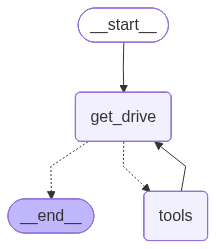

In [6]:
app

In [25]:
result = app.invoke({
    "messages": [
        HumanMessage(content="rename the file kiran punna aiml resume in b drive into kiranpunna")
    ]
})


In [26]:
print(result['messages'][-1].content)

The file "Kiran Punna AIML Resume" in the B drive has been renamed to "kiranpunna".


In [27]:
for msg in result["messages"]:
    print(msg)

content='rename the file kiran punna aiml resume in b drive into kiranpunna' additional_kwargs={} response_metadata={} id='5a295446-27ff-4404-9a6f-1ee1967df9ea'
content='' additional_kwargs={'tool_calls': [{'id': 'chatcmpl-tool-8ed550083175e392', 'type': 'function', 'function': {'name': 'rename_file', 'arguments': '{"file_path": "B:/kiran punna aiml resume", "new_name": "kiranpunna"}'}}]} response_metadata={'role': 'assistant', 'content': None, 'refusal': None, 'annotations': None, 'audio': None, 'function_call': None, 'tool_calls': [{'id': 'chatcmpl-tool-8ed550083175e392', 'type': 'function', 'function': {'name': 'rename_file', 'arguments': '{"file_path": "B:/kiran punna aiml resume", "new_name": "kiranpunna"}'}}], 'reasoning': None, 'reasoning_content': None, 'token_usage': {'prompt_tokens': 2085, 'total_tokens': 2122, 'completion_tokens': 37, 'prompt_tokens_details': None}, 'finish_reason': 'tool_calls', 'model_name': 'meta/llama-3.1-70b-instruct'} id='lc_run--019f181c-2a10-7631-bc5